# Import Required Libraries
Import necessary Python libraries such as `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib` and `seaborn` for visualization, and `sklearn` for model training and preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Datasets
Load the `sample_submission.csv` file. Since the `data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.xls` file is formatted as HTML, use `pd.read_html` to parse it and extract the main DataFrame.

In [2]:
# Load submission file
submission_df = pd.read_csv('dataset/sample_submission.csv')
print(f"Submission shape: {submission_df.shape}")

# Load training data (HTML/Excel format)
# Note: pd.read_html returns a list of dataframes
# We use lxml validation to ensure it parses the HTML correctly
file_path = 'dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.xls'

try:
    train_dfs = pd.read_html(file_path)
    if not train_dfs:
        raise ValueError("No tables found in the file.")
    train_df = train_dfs[0]
    print(f"Training data shape: {train_df.shape}")
except Exception as e:
    print(f"Error loading file: {e}")
    # Define an empty dataframe to prevent NameError in subsequent cells if loading fails
    train_df = pd.DataFrame()
    raise e

train_df.head()

Submission shape: (455, 2)
Training data shape: (3501, 13)


,periode_data,bulan,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202401,1,21,DKI3 Jagakarsa,51.0,65.0,45.0,9.0,8.0,79.0,79.0,NaN,SEDANG
1,202401,1,22,DKI3 Jagakarsa,27.0,34.0,45.0,5.0,8.0,56.0,56.0,NaN,SEDANG
2,202401,1,23,DKI3 Jagakarsa,NaN,52.0,46.0,6.0,9.0,51.0,52.0,PM25,SEDANG
3,202401,1,24,DKI3 Jagakarsa,46.0,65.0,46.0,8.0,9.0,38.0,65.0,PM25,SEDANG
4,202401,1,25,DKI3 Jagakarsa,37.0,55.0,47.0,7.0,11.0,28.0,55.0,PM25,SEDANG


# Preprocess Training Data (XLS)
Clean the historical training data. This involves converting `stasiun` strings (e.g., 'DKI1 Bunderan HI') to standardized codes (e.g., 'DKI1'), handling missing values (e.g., filling or dropping NaNs in 'pm_duakomalima'), and ensuring the target column 'kategori' is clean.

In [3]:
# Standardize Station Names
def clean_station(stasiun):
    if 'DKI1' in stasiun: return 'DKI1'
    if 'DKI2' in stasiun: return 'DKI2'
    if 'DKI3' in stasiun: return 'DKI3'
    if 'DKI4' in stasiun: return 'DKI4'
    if 'DKI5' in stasiun: return 'DKI5'
    return stasiun

train_df['stasiun_code'] = train_df['stasiun'].apply(clean_station)

# Create Date Features from 'tanggal' (assuming it's just day) and 'periode_data' (YYYYMM) or 'bulan'
# The format in the sample HTML looks like: periode_data=202401, bulan=01, tanggal=21
# We'll construct a proper datetime object
train_df['year'] = train_df['periode_data'].astype(str).str[:4].astype(int)
train_df['month'] = train_df['bulan'].astype(int)
train_df['day'] = train_df['tanggal'].replace('N/A', np.nan).fillna(1).astype(int)

# Drop rows with invalid dates if any
train_df = train_df.dropna(subset=['year', 'month', 'day'])

# Handle target category
train_df = train_df.dropna(subset=['kategori'])
train_df = train_df[train_df['kategori'] != 'TIDAK ADA DATA']

# Select features for training (Since submission only has Date + Station, we use those)
features = ['stasiun_code', 'month', 'day']
target = 'kategori'

print("Training Data Sample:")
print(train_df[features + [target]].head())

Training Data Sample:
  stasiun_code  month  day kategori
0         DKI3      1   21   SEDANG
1         DKI3      1   22   SEDANG
2         DKI3      1   23   SEDANG
3         DKI3      1   24   SEDANG
4         DKI3      1   25   SEDANG


# Preprocess Submission File (Feature Extraction)
Parse the `id` column in `sample_submission.csv` (format: `YYYY-MM-DD_DKIx`) to create useful feature columns such as `station`, `month`, and `day_of_week`, making the test data compatible with the training features.

In [4]:
# Parse 'id' column: "2025-09-01_DKI1"
submission_df[['date_str', 'stasiun_code']] = submission_df['id'].str.split('_', expand=True)

# Extract temporal features
submission_df['date'] = pd.to_datetime(submission_df['date_str'])
submission_df['month'] = submission_df['date'].dt.month
submission_df['day'] = submission_df['date'].dt.day
submission_df['year'] = submission_df['date'].dt.year

print("Submission Features Sample:")
print(submission_df[['stasiun_code', 'month', 'day', 'year']].head())

Submission Features Sample:
  stasiun_code  month  day  year
0         DKI1      9    1  2025
1         DKI2      9    1  2025
2         DKI3      9    1  2025
3         DKI4      9    1  2025
4         DKI5      9    1  2025


# Encode Categorical Features
Convert categorical string features (like `stasiun`) into numerical values using `LabelEncoder`. Ensure the target variable `kategori` is also encoded for training.

In [5]:
# Encode Station
le_station = LabelEncoder()
all_stations = pd.concat([train_df['stasiun_code'], submission_df['stasiun_code']]).unique()
le_station.fit(all_stations)

train_df['stasiun_enc'] = le_station.transform(train_df['stasiun_code'])
submission_df['stasiun_enc'] = le_station.transform(submission_df['stasiun_code'])

# Encode Target
le_target = LabelEncoder()
train_df['target_enc'] = le_target.fit_transform(train_df['kategori'])

print("Classes:", le_target.classes_)

Classes: ['BAIK' 'SANGAT TIDAK SEHAT' 'SEDANG' 'TIDAK SEHAT']


# Train Classification Model
Train a multi-class classification model (e.g., `RandomForestClassifier` or `GradientBoostingClassifier`) using features like `station`, `month`, and `day`. Note: Since the submission file only provides Date and Station, the model should primarily rely on temporal and spatial patterns.

In [6]:
# Prepare Data
X = train_df[['stasiun_enc', 'month', 'day']]
y = train_df['target_enc']

# Train Model
# Using Random Forest to capture non-linear temporal/spatial patterns
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

print("Model Trained.")

Model Trained.


# Predict Labels for Submission
Use the trained model to predict the `category` for each row in the preprocessed `sample_submission` DataFrame and decode the numerical predictions back to their original string labels.

In [7]:
# Predict
X_sub = submission_df[['stasiun_enc', 'month', 'day']]
y_pred = model.predict(X_sub)

# Decode predictions
submission_df['category'] = le_target.inverse_transform(y_pred)

print(submission_df[['id', 'category']].head())

                id category
0  2025-09-01_DKI1   SEDANG
1  2025-09-01_DKI2   SEDANG
2  2025-09-01_DKI3   SEDANG
3  2025-09-01_DKI4   SEDANG
4  2025-09-01_DKI5   SEDANG


# Visualize Label Distribution
Calculate the value counts of the predicted categories in the submission file. Create a countplot using `seaborn` to visualize the distribution of labels as requested.

/tmp/ipykernel_36012/2069056191.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=submission_df, order=valid_order, palette='viridis')


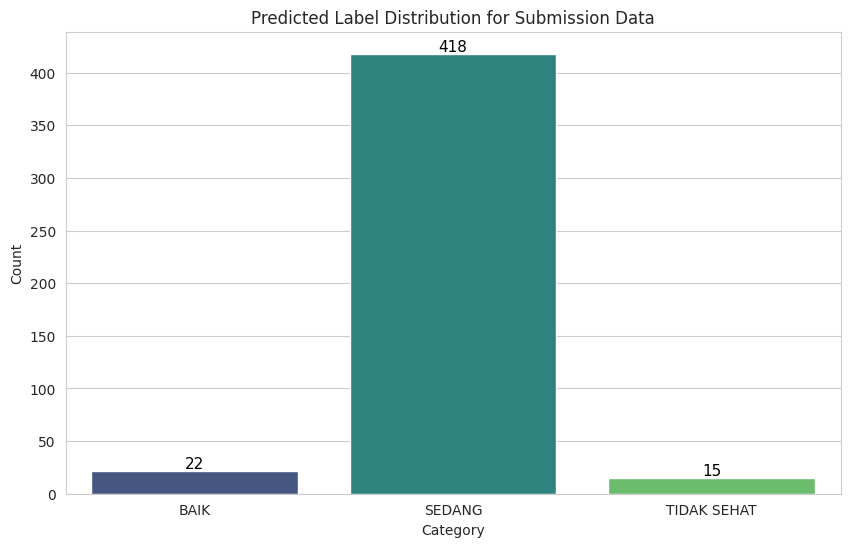

In [8]:
plt.figure(figsize=(10, 6))
order = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
valid_order = [x for x in order if x in submission_df['category'].unique()]

sns.countplot(x='category', data=submission_df, order=valid_order, palette='viridis')
plt.title('Predicted Label Distribution for Submission Data')
plt.xlabel('Category')
plt.ylabel('Count')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()